In [14]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ========== Load and Prepare Data ==========
train_path = r"C:\Users\Aswathi M\Downloads\combined_train.csv"
test_path = r"C:\Users\Aswathi M\Downloads\combined_test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Encode categorical features
def encode_categoricals(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = LabelEncoder().fit_transform(df[col])
    return df

df_train = encode_categoricals(df_train)
df_test = encode_categoricals(df_test)

# Shuffle train data
df_train = shuffle(df_train, random_state=42)

# Split into X and y
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

# ========== Simulate Federated Clients ==========
num_clients = 3
client_data = np.array_split(X_train, num_clients)
client_labels = np.array_split(y_train, num_clients)

client_models = []
num_classes = len(np.unique(y_train))
probs = np.zeros((X_test.shape[0], num_classes))

# ========== Train Local Models ==========
for i in range(num_clients):
    print(f"Training client {i+1} model...")
    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='MultiClass',
        verbose=0
    )
    model.fit(client_data[i], client_labels[i])
    client_models.append(model)
    probs += model.predict_proba(X_test)  # Sum probabilities

# ========== Average Probabilities ==========
probs /= num_clients
y_pred = np.argmax(probs, axis=1)

# ========== Evaluate ==========
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
cat_preds = probs


Training client 1 model...
Training client 2 model...
Training client 3 model...

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.96      0.98      1500

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

=== Confusion Matrix ===
[[1486    0    0   14]
 [   0 1499    1    0]
 [   0    2 1498    0]
 [  56    0    0 1444]]
F1 Score (macro): 0.9878310461628366


In [15]:
# ================================
# Federated Learning with XGBoost
# ================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings("ignore")

# ========== Load and Prepare Data ==========
train_path = r"C:\Users\Aswathi M\Downloads\combined_train.csv"
test_path = r"C:\Users\Aswathi M\Downloads\combined_test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Encode categorical features
def encode_categoricals(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = LabelEncoder().fit_transform(df[col])
    return df

df_train = encode_categoricals(df_train)
df_test = encode_categoricals(df_test)

# Shuffle train data
df_train = shuffle(df_train, random_state=42)

# Split into X and y
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

# ========== Simulate Federated Clients ==========
num_clients = 3
client_data = np.array_split(X_train, num_clients)
client_labels = np.array_split(y_train, num_clients)

client_models = []
num_classes = len(np.unique(y_train))
probs = np.zeros((X_test.shape[0], num_classes))

# ========== Train Local Models ==========
for i in range(num_clients):
    print(f"Training XGBoost model for client {i+1}...")

    dtrain = xgb.DMatrix(client_data[i], label=client_labels[i])
    dtest = xgb.DMatrix(X_test)

    params = {
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'max_depth': 6,
        'eta': 0.1,
        'eval_metric': 'mlogloss',
        'verbosity': 0
    }

    bst = xgb.train(params, dtrain, num_boost_round=200)
    client_models.append(bst)

    probs += bst.predict(dtest)

# ========== Average Predictions ==========
probs /= num_clients
y_pred = np.argmax(probs, axis=1)

# ========== Evaluation ==========
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
xgb_preds = probs


Training XGBoost model for client 1...
Training XGBoost model for client 2...
Training XGBoost model for client 3...

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.99      0.99      1500

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

=== Confusion Matrix ===
[[1486    0    0   14]
 [   0 1499    1    0]
 [   0    2 1498    0]
 [  22    0    0 1478]]
F1 Score (macro): 0.9934999572774743


In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# ========== Load Data ==========
train_path = r"C:\Users\Aswathi M\Downloads\combined_train.csv"
test_path = r"C:\Users\Aswathi M\Downloads\combined_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ========== Preprocessing ==========
# Keep only numeric columns
train_df = train_df.select_dtypes(include=[np.number])
test_df = test_df.select_dtypes(include=[np.number])

# Show label distribution
print("Train label distribution:\n", train_df['label'].value_counts())
print("\nTest label distribution:\n", test_df['label'].value_counts())

# Split features and labels
X_train_full = train_df.drop('label', axis=1)
y_train_full = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# Normalize data
scaler = StandardScaler()
X_train_full = pd.DataFrame(scaler.fit_transform(X_train_full), columns=X_train_full.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# ========== Simulated Federated Learning ==========
n_clients = 3
client_data = []
X_splits = np.array_split(X_train_full, n_clients)
y_splits = np.array_split(y_train_full, n_clients)

for i in range(n_clients):
    client_data.append((X_splits[i], y_splits[i]))

# Global validation set (simulate a secure central location)
X_val = X_test
y_val = y_test


# ========== Train Local Models ==========
client_predictions = []
params = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 4,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1
}

for i, (X_client, y_client) in enumerate(client_data):
    print(f"\nTraining model for client {i+1}...")
    train_data = lgb.Dataset(X_client, label=y_client)
    model = lgb.train(params, train_data, num_boost_round=100)
    preds = model.predict(X_val)
    client_predictions.append(preds)

# ========== Aggregate Predictions ==========
avg_preds = np.mean(client_predictions, axis=0)
y_pred = np.argmax(avg_preds, axis=1)

# ========== Evaluate ==========
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nAccuracy Score:", accuracy_score(y_val, y_pred))
lgb_preds = avg_preds


Train label distribution:
 label
0    5000
1    5000
2    5000
3    5000
Name: count, dtype: int64

Test label distribution:
 label
0    1500
1    1500
2    1500
3    1500
Name: count, dtype: int64

Training model for client 1...

Training model for client 2...

Training model for client 3...

Confusion Matrix:
 [[1263    1    1  235]
 [   2 1489    9    0]
 [   0    1 1499    0]
 [ 413  128    2  957]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.84      0.79      1500
           1       0.92      0.99      0.95      1500
           2       0.99      1.00      1.00      1500
           3       0.80      0.64      0.71      1500

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.86      6000
weighted avg       0.87      0.87      0.86      6000


Accuracy Score: 0.868


=== Ensemble Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.98      0.99      1500

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

=== Ensemble Confusion Matrix ===
[[1486    0    0   14]
 [   0 1499    1    0]
 [   0    2 1498    0]
 [  28    0    0 1472]]
Ensemble Accuracy: 0.9925
Ensemble F1 Score (macro): 0.99249984749668


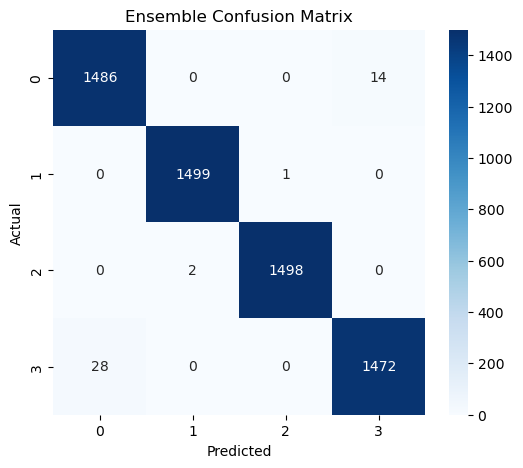

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# ========== Ensemble ==========
# Average the probability predictions from the 3 models
ensemble_probs = (lgb_preds + xgb_preds + cat_preds) / 3
ensemble_pred = np.argmax(ensemble_probs, axis=1)

# ========== Evaluation ==========
print("=== Ensemble Classification Report ===")
print(classification_report(y_test, ensemble_pred))

print("=== Ensemble Confusion Matrix ===")
print(confusion_matrix(y_test, ensemble_pred))

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))
print("Ensemble F1 Score (macro):", f1_score(y_test, ensemble_pred, average='macro'))

# ========== Optional: Plot Confusion Matrix ==========
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, ensemble_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


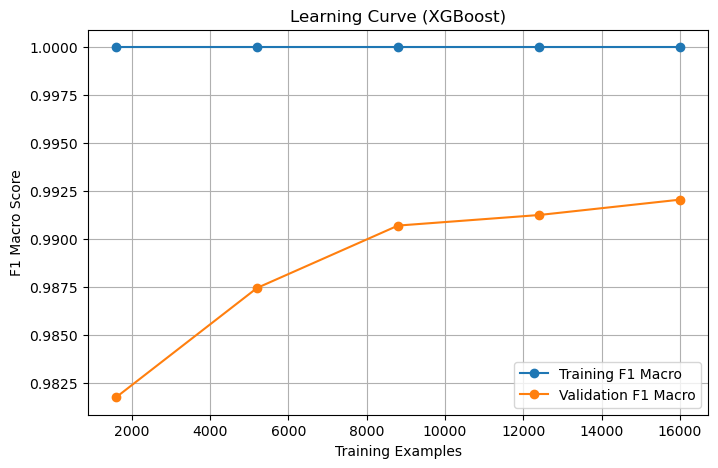

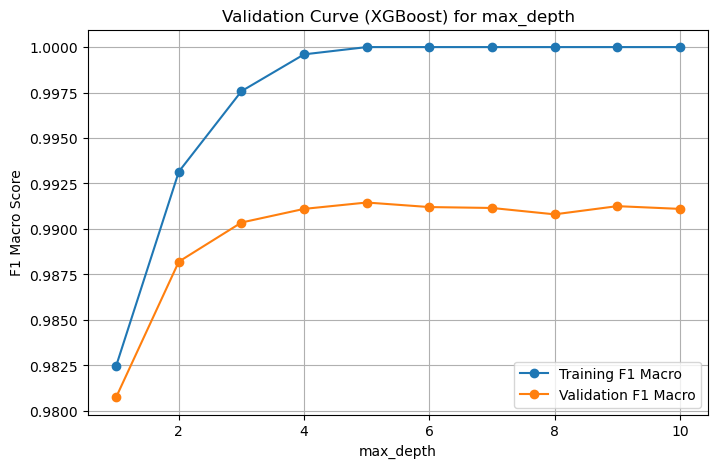

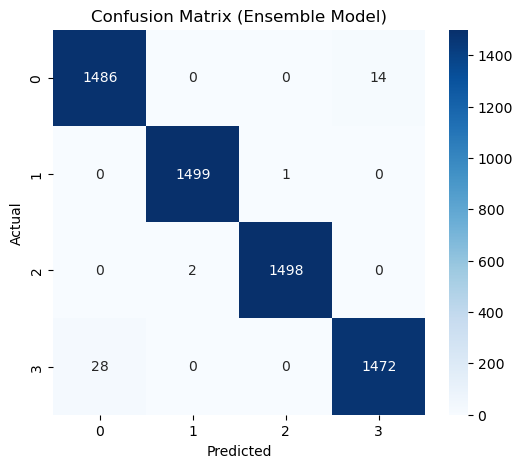

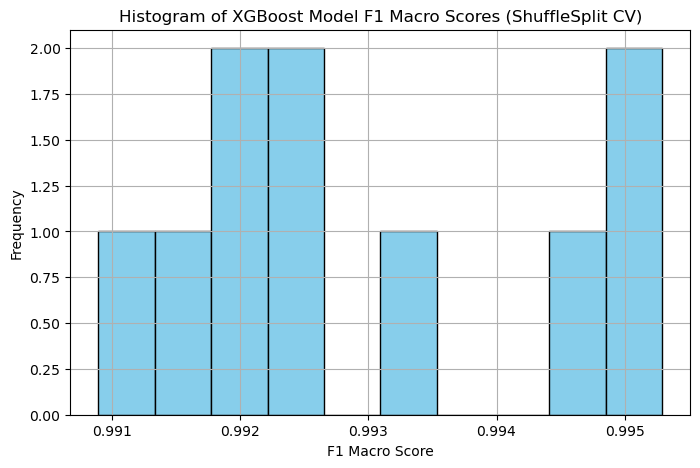

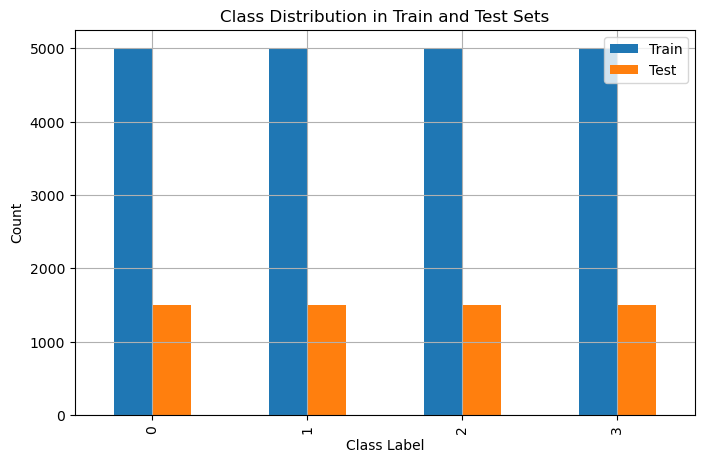

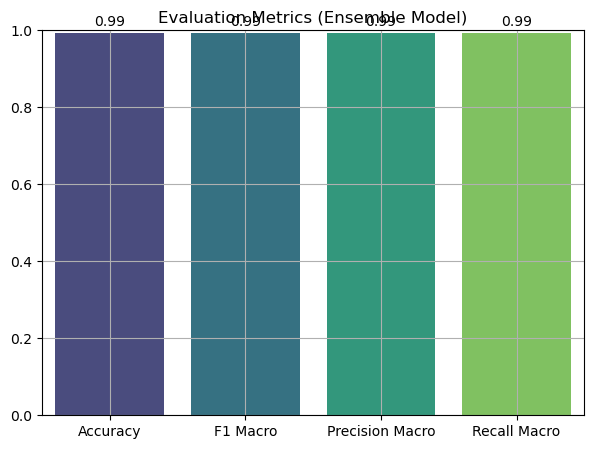

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, validation_curve, ShuffleSplit, cross_val_score
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report
)
import numpy as np
import pandas as pd
import xgboost as xgb

# ====================================
# Assume already defined:
# - X_train, y_train, X_test, y_test
# - ensemble_pred, lgb_preds, xgb_preds, cat_preds
# ====================================

# ========== 1. Learning Curve ==========
def plot_learning_curve(model, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )

    train_scores_mean = train_scores.mean(axis=1)
    val_scores_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores_mean, 'o-', label='Training F1 Macro')
    plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation F1 Macro')
    plt.title("Learning Curve (XGBoost)")
    plt.xlabel("Training Examples")
    plt.ylabel("F1 Macro Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# ========== 2. Validation Curve ==========
def plot_validation_curve(param_name='max_depth', param_range=range(1, 11)):
    model = xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y_train)), eval_metric='mlogloss')
    train_scores, val_scores = validation_curve(
        model, X_train, y_train, param_name=param_name, param_range=param_range,
        cv=3, scoring='f1_macro', n_jobs=-1
    )

    train_scores_mean = train_scores.mean(axis=1)
    val_scores_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(param_range, train_scores_mean, 'o-', label='Training F1 Macro')
    plt.plot(param_range, val_scores_mean, 'o-', label='Validation F1 Macro')
    plt.title(f"Validation Curve (XGBoost) for {param_name}")
    plt.xlabel(param_name)
    plt.ylabel("F1 Macro Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# ========== 3. Confusion Matrix ==========
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix (Ensemble Model)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ========== 4. ShuffleSplit Histogram ==========
def plot_model_histogram():
    model = xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y_train)))
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

    plt.figure(figsize=(8, 5))
    plt.hist(scores, bins=10, color='skyblue', edgecolor='black')
    plt.title("Histogram of XGBoost Model F1 Macro Scores (ShuffleSplit CV)")
    plt.xlabel("F1 Macro Score")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# ========== 5. Class Distribution ==========
def plot_class_distribution():
    train_dist = y_train.value_counts().sort_index()
    test_dist = y_test.value_counts().sort_index()

    df = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
    df.plot(kind='bar', figsize=(8, 5))
    plt.title("Class Distribution in Train and Test Sets")
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

# ========== 6. Evaluation Metrics ==========
def plot_eval_metrics(y_true, y_pred):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 Macro': f1_score(y_true, y_pred, average='macro'),
        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Recall Macro': recall_score(y_true, y_pred, average='macro')
    }

    plt.figure(figsize=(7, 5))
    sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
    plt.title("Evaluation Metrics (Ensemble Model)")
    plt.ylim(0, 1)
    for i, v in enumerate(metrics.values()):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    plt.grid(True)
    plt.show()

# ======================
# PLOT ALL
# ======================
xgb_model_for_curve = xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y_train)))
plot_learning_curve(xgb_model_for_curve, X_train.values, y_train.values)
plot_validation_curve()
plot_confusion_matrix(y_test, ensemble_pred)
plot_model_histogram()
plot_class_distribution()
plot_eval_metrics(y_test, ensemble_pred)
